# Power Analysis

This chapter follows a small treatment study from exploratory data to study design. We will visualize dummy control and treatment measurements, run a two-sample test, demonstrate how selective analysis can create misleading small p-values, and use power analysis to plan a future study.

The p-hacking example is a warning about analytical flexibility, not a recommended practice. The power calculation is prospective: it uses a meaningful target effect and assumptions chosen before collecting data.

## Scenario and learning goals

Suppose a research team is comparing a new treatment with a control. The outcome is a continuous measurement, and a higher value is considered better. The first dataset is simulated for teaching; it is not evidence about a real treatment.

After working through the example, you should be able to explain a p-value, recognize why selecting the most favorable analysis inflates false positives, and calculate a sample size for a future two-group study.

In [27]:
# Install these packages once if they are not already available.
required_packages <- c("ggplot2", "pwr")
missing_packages <- required_packages[
  !vapply(required_packages, requireNamespace, logical(1), quietly = TRUE)
]
if (length(missing_packages) > 0) {
  install.packages(missing_packages)
}

library(ggplot2)
library(pwr)

## Simulate treatment and control data

We create 24 observations in each group. The simulated treatment group has a higher average, with individual variation in both groups. The random seed makes the example reproducible.

In [ ]:
set.seed(2026)
n_per_group <- 24
study_data <- data.frame(
  group = factor(
    rep(c("Control", "Treatment"), each = n_per_group),
    levels = c("Control", "Treatment")
  ),
  outcome = c(
    rnorm(n_per_group, mean = 50, sd = 12),
    rnorm(n_per_group, mean = 58, sd = 12)
  )
)

aggregate(outcome ~ group, data = study_data,
          FUN = function(x) c(n = length(x), mean = mean(x), sd = sd(x)))

## Visualize the outcome distributions

The violin and boxplots summarize each group, while the jittered points show individual simulated observations. Plotting the raw data helps us see spread and overlap, not just the difference between group means.

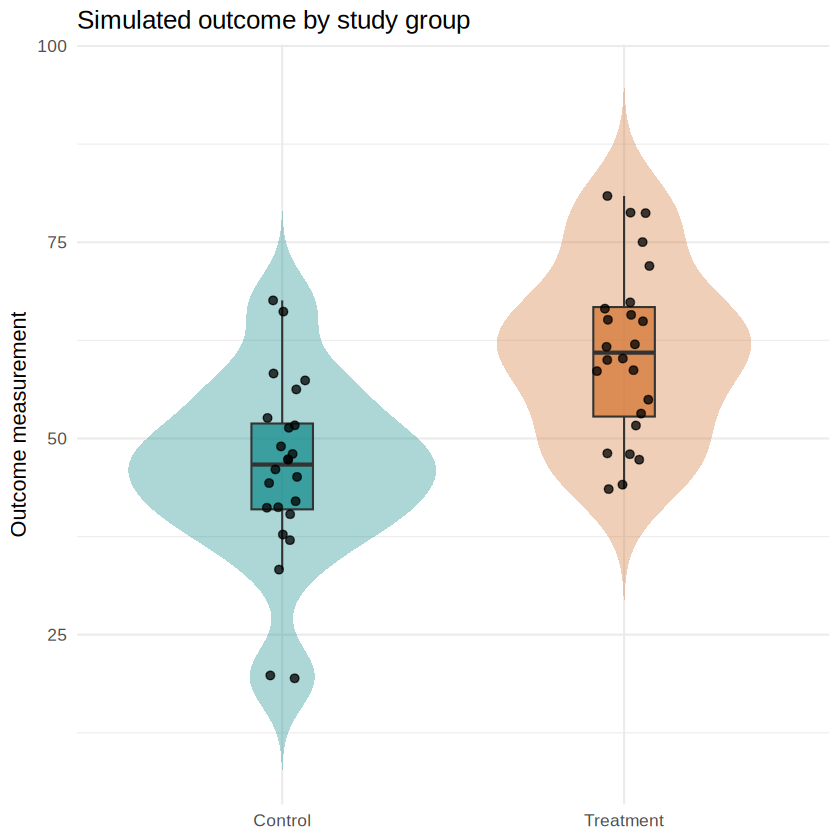

In [28]:
ggplot(study_data, aes(x = group, y = outcome, fill = group)) +
  geom_violin(alpha = 0.35, trim = FALSE, color = NA) +
  geom_boxplot(width = 0.18, outlier.shape = NA, alpha = 0.75) +
  geom_jitter(width = 0.08, alpha = 0.75, size = 2) +
  scale_fill_manual(values = c("Control" = "#168C8C",
                                "Treatment" = "#D47735")) +
  labs(
    title = "Simulated outcome by study group",
    x = NULL,
    y = "Outcome measurement"
  ) +
  theme_minimal(base_size = 13) +
  theme(legend.position = "none")

## Run a two-sample test

A two-sided Welch two-sample t-test evaluates whether the population means differ, without assuming equal group variances. The p-value is the probability, under the null hypothesis and the test assumptions, of getting a test statistic at least as extreme as the one observed. It is **not** the probability that the null hypothesis is true, nor a measure of the size or importance of an effect.

The result from one small simulated study can vary with the random sample. The code reports the estimated mean difference and confidence interval alongside the p-value.

In [29]:
test_result <- t.test(outcome ~ group, data = study_data,
                      alternative = "two.sided")
test_result

mean_by_group <- aggregate(outcome ~ group, study_data, mean)
mean_by_group
mean_by_group$outcome[mean_by_group$group == "Treatment"] -
  mean_by_group$outcome[mean_by_group$group == "Control"]


	Welch Two Sample t-test

data:  outcome by group
t = -4.6478, df = 45.796, p-value = 2.857e-05
alternative hypothesis: true difference in means between group Control and group Treatment is not equal to 0
95 percent confidence interval:
 -21.883321  -8.655782
sample estimates:
  mean in group Control mean in group Treatment 
               45.85541                61.12496 


group,outcome
<fct>,<dbl>
Control,45.85541
Treatment,61.12496


[1] 15.26955

## How p-hacking creates misleading evidence

P-hacking is selectively trying analyses, outcomes, subgroups, or stopping rules and emphasizing the result that gives the smallest p-value, without transparently reporting all those choices. Under a true null effect, each correctly planned test has a 5% false-positive rate at $\alpha = 0.05$. Repeating tests and only reporting a significant one raises the chance of a false discovery.

The simulation below assumes 20 independent outcomes and no treatment effect on any of them. It compares one pre-specified test, the smallest p-value selected from all 20, and a family-wise Holm correction. The independence assumption makes the illustration simple; real analyses can have correlated outcomes and many other sources of flexibility.

### Optional stopping: adding participants after checking the p-value

Imagine starting with 4 participants per group, adding one participant to each group at a time, and running the same two-sided t-test after every addition. If recruitment is stopped as soon as p < 0.05, the stopping decision depends on the observed results. Repeatedly testing at the ordinary 0.05 threshold without adjustment inflates the chance of a false positive. This is called optional stopping and is one form of p-hacking when it is unplanned or selectively reported.

The graph below summarizes 100 simulated studies with **no true group difference**. One line shows the proportion that is significant at each sample size; the other shows the cumulative proportion that has crossed 0.05 at least once. P-values fluctuate rather than steadily falling, but the cumulative chance of having seen a false positive increases as more unadjusted looks are taken.

Null studies with at least one p < 0.05: 12 % of 100 


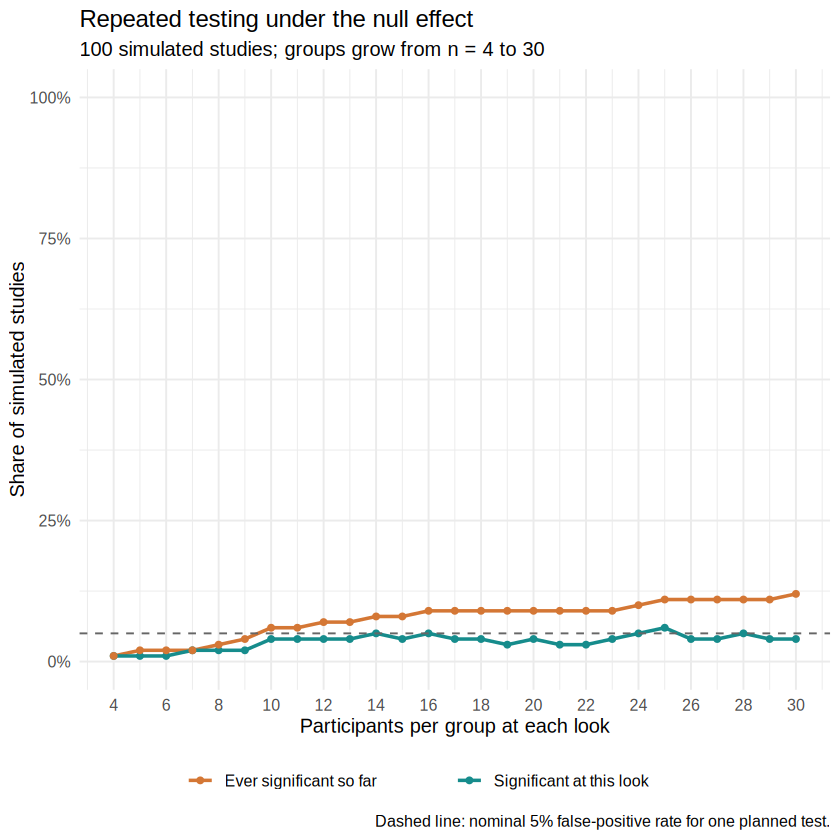

In [30]:
set.seed(318)
max_n_per_group <- 30
sample_sizes <- 4:max_n_per_group
n_demo_studies <- 100

# Each column is one independent null-effect study with balanced groups.
demo_p_values <- replicate(n_demo_studies, {
  control <- rnorm(max_n_per_group, mean = 0, sd = 1)
  treatment <- rnorm(max_n_per_group, mean = 0, sd = 1)
  vapply(sample_sizes, function(n) {
    t.test(treatment[seq_len(n)], control[seq_len(n)])$p.value
  }, numeric(1))
})

significant_this_look <- rowMeans(demo_p_values < 0.05)
cumulative_significant <- vapply(seq_along(sample_sizes), function(look) {
  mean(colSums(demo_p_values[seq_len(look), , drop = FALSE] < 0.05) > 0)
}, numeric(1))

p_hacking_summary <- data.frame(
  n_per_group = sample_sizes,
  significant_this_look = significant_this_look,
  ever_significant = cumulative_significant
)

final_ever_significant <- tail(p_hacking_summary$ever_significant, 1)
cat("Null studies with at least one p < 0.05:",
    round(100 * final_ever_significant, 1), "% of", n_demo_studies, "\n")

p_hacking_plot_data <- rbind(
  data.frame(
    n_per_group = sample_sizes,
    rate = significant_this_look,
    pattern = "Significant at this look"
  ),
  data.frame(
    n_per_group = sample_sizes,
    rate = cumulative_significant,
    pattern = "Ever significant so far"
  )
)

ggplot(p_hacking_plot_data,
       aes(x = n_per_group, y = rate, color = pattern)) +
  geom_line(linewidth = 1) +
  geom_point(size = 1.5) +
  geom_hline(yintercept = 0.05, linetype = "dashed", color = "grey40") +
  scale_color_manual(values = c(
    "Significant at this look" = "#168C8C",
    "Ever significant so far" = "#D47735"
  )) +
  scale_y_continuous(
    labels = function(rate) paste0(round(rate * 100), "%"),
    limits = c(0, 1)
  ) +
  scale_x_continuous(breaks = seq(4, max_n_per_group, by = 2)) +
  labs(
    title = "Repeated testing under the null effect",
    subtitle = paste(n_demo_studies,
                     "simulated studies; groups grow from n = 4 to 30"),
    x = "Participants per group at each look",
    y = "Share of simulated studies",
    color = NULL,
    caption = "Dashed line: nominal 5% false-positive rate for one planned test."
  ) +
  theme_minimal(base_size = 12) +
  theme(legend.position = "bottom")

#### Compare false-positive rates across many null studies

One trajectory can be unusual, so repeat the comparison across many simulated studies where the treatment has no effect. We compare a single test at the pre-specified final sample size (30 per group) with checking after each balanced addition from 4 through 30 per group and declaring success if any unadjusted p-value is below 0.05. The repeated-look strategy is deliberately naive; real group-sequential studies use pre-planned stopping boundaries or alpha-spending methods.

In [ ]:
set.seed(902)
n_simulations <- 5000
n_looks <- length(sample_sizes)

control_simulations <- matrix(
  rnorm(n_simulations * max_n_per_group),
  nrow = n_simulations
)
treatment_simulations <- matrix(
  rnorm(n_simulations * max_n_per_group),
  nrow = n_simulations
)

welch_p_values <- function(control, treatment, n) {
  control_n <- control[, seq_len(n), drop = FALSE]
  treatment_n <- treatment[, seq_len(n), drop = FALSE]
  control_mean <- rowMeans(control_n)
  treatment_mean <- rowMeans(treatment_n)
  control_variance <- rowSums((control_n - control_mean)^2) / (n - 1)
  treatment_variance <- rowSums((treatment_n - treatment_mean)^2) / (n - 1)
  control_component <- control_variance / n
  treatment_component <- treatment_variance / n
  standard_error <- sqrt(control_component + treatment_component)
  t_statistic <- (treatment_mean - control_mean) / standard_error
  degrees_freedom <- (control_component + treatment_component)^2 /
    (control_component^2 / (n - 1) + treatment_component^2 / (n - 1))
  2 * pt(-abs(t_statistic), df = degrees_freedom)
}

simulation_p_values <- vapply(sample_sizes, function(n) {
  welch_p_values(control_simulations, treatment_simulations, n)
}, numeric(n_simulations))

fixed_sample_false_positive <- mean(simulation_p_values[, n_looks] < 0.05)
repeated_look_false_positive <- mean(
  apply(simulation_p_values < 0.05, 1, any)
)

false_positive_comparison <- data.frame(
  strategy = c("One planned test at n = 30", "Check repeatedly; stop at p < 0.05"),
  false_positive_rate = c(fixed_sample_false_positive,
                          repeated_look_false_positive)
)
false_positive_comparison$percent <-
  100 * false_positive_comparison$false_positive_rate
false_positive_comparison

ggplot(false_positive_comparison,
       aes(x = strategy, y = percent, fill = strategy)) +
  geom_col(width = 0.62, show.legend = FALSE) +
  geom_hline(yintercept = 5, linetype = "dashed", color = "firebrick") +
  geom_text(aes(label = sprintf("%.1f%%", percent)),
            vjust = -0.45, size = 4) +
  scale_fill_manual(values = c("#168C8C", "#D47735")) +
  coord_cartesian(ylim = c(0, max(false_positive_comparison$percent) + 8)) +
  labs(
    title = "False positives under the null effect",
    subtitle = paste("Simulated studies:", n_simulations,
                     "| repeated looks from n = 4 to 30 per group"),
    x = NULL,
    y = "Studies declared significant (%)"
  ) +
  theme_minimal(base_size = 12) +
  theme(axis.text.x = element_text(angle = 8, hjust = 1))

In [ ]:
set.seed(410)
n_studies <- 2000
n_per_group_null <- 20
n_outcomes <- 20

# Every outcome has the same null distribution in both groups.
p_values <- replicate(n_outcomes, {
  replicate(n_studies, {
    control <- rnorm(n_per_group_null, mean = 0, sd = 1)
    treatment <- rnorm(n_per_group_null, mean = 0, sd = 1)
    t.test(treatment, control)$p.value
  })
})

one_planned_test <- p_values[, 1]
smallest_selected_p <- apply(p_values, 1, min)
holm_any_significant <- apply(p_values, 1, function(p) {
  any(p.adjust(p, method = "holm") < 0.05)
})

false_positive_rates <- data.frame(
  approach = c("One pre-specified test",
              "Select smallest of 20",
              "20 tests with Holm correction"),
  rate = c(mean(one_planned_test < 0.05),
           mean(smallest_selected_p < 0.05),
           mean(holm_any_significant))
)
false_positive_rates$rate_percent <- 100 * false_positive_rates$rate
false_positive_rates

In [ ]:
ggplot(false_positive_rates,
       aes(x = approach, y = rate_percent, fill = approach)) +
  geom_col(width = 0.68, show.legend = FALSE) +
  geom_hline(yintercept = 5, linetype = "dashed",
             color = "firebrick", linewidth = 0.8) +
  geom_text(aes(label = sprintf("%.1f%%", rate_percent)),
            vjust = -0.45, size = 4) +
  scale_fill_manual(values = c("#168C8C", "#D47735", "#5A7DA8")) +
  coord_cartesian(ylim = c(0, max(false_positive_rates$rate_percent) + 8)) +
  labs(
    title = "False-positive rates when every effect is null",
    subtitle = "Dashed line marks the nominal 5% level",
    x = NULL,
    y = "Studies with at least one reported positive (%)"
  ) +
  theme_minimal(base_size = 12) +
  theme(axis.text.x = element_text(angle = 12, hjust = 1))

The selected-smallest-p approach is intentionally invalid: it hides the 19 other tests and their role in the decision. The nominal 5% threshold applies to a single pre-specified test, not to a search across many results. Holm correction is one way to control the family-wise error rate when multiple hypotheses are genuinely part of the analysis; it does not replace transparent reporting or a sound study design.

Pre-specify primary outcomes and analyses, report all tested outcomes and subgroups, and distinguish confirmatory analyses from exploratory ones. Do not use power analysis as a way to justify searching for significance after seeing the data.

## Design a study using power analysis

Power is the probability of rejecting the null hypothesis when a specified alternative is true. It equals $1 - \beta$, where $\beta$ is the Type II error probability. A prospective calculation connects four quantities: sample size, effect size, variability, and significance level. When three are chosen, the calculation solves for the fourth.

For a two-independent-group t-test, Cohen's $d$ is the mean difference divided by the pooled standard deviation. We will plan for a standardized difference of $d = 0.5$, two-sided $\alpha = 0.05$, and 80% power. These should be justified from subject knowledge, prior studies, or a smallest effect worth detecting, not selected to guarantee a desired result.

In [ ]:
target_d <- 0.5
target_power <- 0.80
alpha <- 0.05

sample_size_result <- pwr.t.test(
  d = target_d,
  sig.level = alpha,
  power = target_power,
  type = "two.sample",
  alternative = "two.sided"
)
sample_size_result

n_per_group <- ceiling(sample_size_result$n)
total_sample_size <- 2 * n_per_group
c(n_per_group = n_per_group, total_sample_size = total_sample_size)

`pwr.t.test()` returns a potentially fractional sample size per group. Round up because a study cannot enroll a fraction of a participant, then report both the per-group and total number. This calculation assumes independent groups, a continuous outcome, an approximately normal outcome (or adequate sample size), the specified effect size, and the test named above. Add a justified allowance for expected attrition separately; do not silently reduce the planned sample after calculating power.

## Explore sample size and effect size

Power is not a fixed property of a test: it depends on the effect size and sample size, among other assumptions. The first plot shows how the required sample size per group changes with the target standardized effect when alpha and power are held fixed. Smaller effects generally require larger samples.

In [ ]:
effect_sizes <- seq(0.2, 0.8, by = 0.05)
required_n <- vapply(effect_sizes, function(effect) {
  pwr.t.test(d = effect, power = target_power, sig.level = alpha,
              type = "two.sample", alternative = "two.sided")$n
}, numeric(1))

power_plan <- data.frame(
  effect_size = effect_sizes,
  n_per_group = ceiling(required_n)
)

ggplot(power_plan, aes(x = effect_size, y = n_per_group)) +
  geom_line(color = "#168C8C", linewidth = 1) +
  geom_point(color = "#D47735", size = 2) +
  labs(
    title = "Required sample size for 80% power",
    x = "Target standardized effect (Cohen's d)",
    y = "Participants per group"
  ) +
  theme_minimal(base_size = 13)

The next plot fixes the target effect at $d = 0.5$ and shows estimated power as the sample size per group increases. The dashed lines mark the conventional 80% target and the sample size calculated above. These curves are planning aids under stated assumptions, not guarantees about a future study.

In [ ]:
sample_sizes <- seq(10, max(100, n_per_group + 20), by = 2)
achieved_power <- vapply(sample_sizes, function(sample_n) {
  pwr.t.test(n = sample_n, d = target_d, sig.level = alpha,
              type = "two.sample", alternative = "two.sided")$power
}, numeric(1))

power_curve <- data.frame(n_per_group = sample_sizes, power = achieved_power)

ggplot(power_curve, aes(x = n_per_group, y = power)) +
  geom_line(color = "#168C8C", linewidth = 1) +
  geom_hline(yintercept = target_power, linetype = "dashed",
             color = "firebrick") +
  geom_vline(xintercept = n_per_group, linetype = "dashed",
             color = "#D47735") +
  coord_cartesian(ylim = c(0, 1)) +
  labs(
    title = "Power versus sample size per group",
    x = "Participants per group",
    y = "Power"
  ) +
  theme_minimal(base_size = 13)

## Study-design checklist

1. Define one primary outcome and a scientifically meaningful target effect.
2. Estimate variability from relevant prior data or a pilot study.
3. Choose the test, significance level, target power, allocation ratio, and sidedness before data collection.
4. Calculate and round up the required sample size; account for attrition transparently.
5. Plan recruitment, randomization, measurement, and analysis to minimize bias.
6. Report assumptions and all planned primary analyses.

Power analysis cannot fix biased measurements, poor randomization, selective reporting, or an implausible effect-size assumption. It is one part of a sound study design.